In [ ]:
import torch
import torch.nn as torch_nn
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm 
import matplotlib.pyplot as plt

import core.utils as utils
import core.plots as plots
import core.models as models

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

train_7x14 = True  # Set to True to train NAF for 7x7 -> 14x14, False for 14x14 -> 28x28

import sys
import os


naf_path = os.path.abspath('naf')
if naf_path not in sys.path:
    sys.path.insert(0, naf_path)
from naf.src.model import NAF 

/home/lukas/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:0
Kornia is not installed. Please install it to use the JBF upsampler.
Kornia is not installed. Please install it to use the JBF upsampler.


torch.Size([1, 198, 100, 100])
torch.Size([1, 4, 100, 100])
torch.Size([198, 4])
[408.38, 417.84000000000003, 427.3, 436.76, 446.22, 455.68, 465.14, 474.6, 484.06, 493.52, 502.98, 512.44, 521.9, 531.36, 540.82, 550.28, 559.74, 569.2, 578.6600000000001, 588.12, 597.58, 607.04, 616.5, 625.96, 635.4200000000001, 644.88, 654.34, 663.8, 673.26, 682.72, 692.1800000000001, 701.6400000000001, 711.1, 720.5600000000001, 730.02, 739.48, 748.94, 758.4000000000001, 767.86, 777.32, 786.78, 796.24, 805.7, 815.1600000000001, 824.6200000000001, 834.08, 843.54, 853.0, 862.46, 871.9200000000001, 881.3800000000001, 890.84, 900.3000000000001, 909.76, 919.22, 928.6800000000001, 938.1400000000001, 947.6, 957.0600000000001, 966.5200000000001, 975.98, 985.44, 994.9000000000001, 1004.36, 1013.82, 1023.2800000000001, 1032.74, 1042.2, 1051.66, 1061.1200000000001, 1070.58, 1080.04, 1089.5, 1098.96, 1108.42, 1117.88, 1127.3400000000001, 1136.8000000000002, 1146.2600000000002, 1155.72, 1165.18, 1174.64, 1184.1, 1193

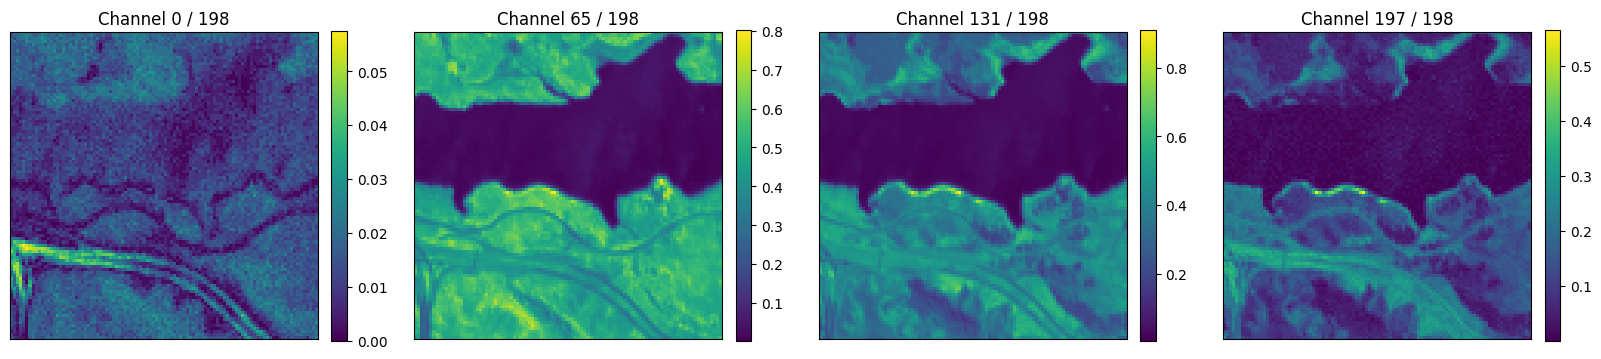

In [2]:
"""Load the HSI and visualize it"""
dataset = "jasper"
Y_init, A_init, E_init, wavelengths = utils.load_hsi(dataset, normalize_Y=True)
B, c, H = Y_init.shape[1], A_init.shape[1], Y_init.shape[-1]


print(Y_init.shape)
print(A_init.shape)
print(E_init.shape)
print(wavelengths)

print(f"HSI of shape {B, H, H} with {c} endmembers")
plots.plot_hsi(Y_init)

In [ ]:
    # --- Initialisation des modèles ---
dofa, Y_dofa, A_dofa, new_H = models.create_dofa(Y_init, A_init, path="dofaweights")
dofa = dofa.to(dev)
spectral_earth = models.create_spectralearth(dev, path="spectral_earth/data")
naf = NAF(in_channels=128).to(dev)
checkpoint = torch.load("naf_hyperspectral_best_7x14.pth", map_location=dev)

naf.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
    



Y = Y_init.to(dev)

native_h, native_w = Y.shape[2], Y.shape[3]
print(f"Image native : {native_h}x{native_w}, {Y.shape[1]} canaux, {Y.shape[0]} batch(es)")


Image native : 100x100, 198 canaux, 1 batch(es)


In [ ]:


# INITIALISATION DU MODÈLE DE DÉMÉLANGE (CORRIGÉ)

D_naf = 1024 

alpha = native_h


model = models.Unmixing_from_features(D=D_naf, B=B, H=native_h, c=c, alpha=alpha).to(dev)

model.apply(model.weights_init)
model = models.init_decoder_weights(model, Y/Y.max(), c)

epochs, lr = 200, 0.002
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=0.18)


Nombre de canaux D pour le modèle de démélange : 1024


Shapes - E_hat: torch.Size([198, 4]), A_hat: torch.Size([1, 4, 100, 100]), A_init: torch.Size([1, 4, 224, 224]), E_init: torch.Size([198, 4])


RuntimeError: The size of tensor a (224) must match the size of tensor b (100) at non-singleton dimension 2

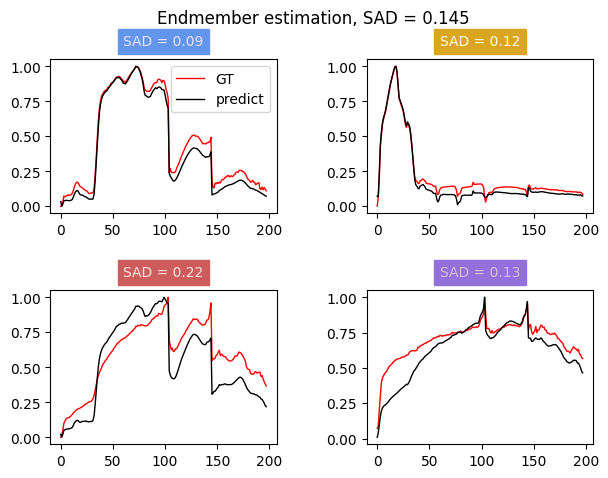

In [ ]:


# BOUCLE D'ENTRAÎNEMENT


print("Entraînement du réseau de démélange...")
for epoch in tqdm(range(epochs)):

    optimizer.zero_grad()


    with torch.no_grad():
        guidance_hr = models.spectral_adapter(spectral_earth, Y)
        feat_lr = models.extract_features(dofa, Y, wavelengths)
        
        # Sécurité pour les dimensions Batch
        if len(feat_lr.shape) == 3: feat_lr = feat_lr.unsqueeze(0)
        if len(guidance_hr.shape) == 3: guidance_hr = guidance_hr.unsqueeze(0)
        
        naf_features = naf(guidance_hr, feat_lr, output_size=(native_h, native_w))
        naf_features = naf_features.detach()
        
        if len(naf_features.shape) == 4: naf_features = naf_features.squeeze(0)
   

    # Passage dans le modèle de démélange
    E_hat, A_hat, Y_hat = model(naf_features.detach())

    # Calcul de la perte avec l'image native Y
    loss = model.loss(Y, Y_hat, A_hat, E_hat)
    if torch.isnan(loss).any() or torch.isinf(loss).any():
        print("ALERTE : La loss contient des NaN ou Inf ! Arrêt avant le crash.")
        break
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
    optimizer.step()

    with torch.no_grad():
        constraints = models.weightConstraint()
        model.decoder.apply(constraints)


# ÉVALUATION FINALE

model.eval()

with torch.no_grad():
    guidance_hr = models.spectral_adapter(spectral_earth, Y)
    feat_lr = models.extract_features(dofa, Y, wavelengths)
    
    if len(feat_lr.shape) == 3: feat_lr = feat_lr.unsqueeze(0)
    if len(guidance_hr.shape) == 3: guidance_hr = guidance_hr.unsqueeze(0)
    
    naf_features = naf(guidance_hr, feat_lr, output_size=(native_h, native_w))
    if len(naf_features.shape) == 4: naf_features = naf_features.squeeze(0)

    # Prédiction finale
    E_hat, A_hat, Y_hat = model(naf_features)
    
    # Évaluation (avec A_init, la vraie carte 110x110)
    print(f"Shapes - E_hat: {E_hat.shape}, A_hat: {A_hat.shape}, A_init: {A_dofa.shape}, E_init: {E_init.shape}")
    sad, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_dofa, E_init)